In [18]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [19]:
df = pd.read_excel(
    r"C:\Users\Neethu\Documents\ML\Department Awareness Survey (Responses).xlsx"
)


print("FIRST 5 ROWS")
print(df.head())


print("\nDATASET SHAPE")
print(df.shape)


FIRST 5 ROWS
                Timestamp Registration Number   \
0 2026-06-22 08:49:31.362              2547123   
1 2026-06-22 08:49:50.520              2547122   
2 2026-06-22 08:50:44.521              2547101   
3 2026-06-22 08:51:00.666              2547156   
4 2026-06-22 08:51:42.357              2547148   

                                          Email  \
0         jiyaelza.jabi@mca.christuniversity.in   
1  jinishaleema.rosario@mca.christuniversity.in   
2        rajeev.chandar@mca.christuniversity.in   
3    sounak.chakraborty@mca.christuniversity.in   
4         samar.subhash@mca.christuniversity.in   

  Job role that you are interested in\n  \
0                     Software Engineer   
1                         Data Engineer   
2                     Software Engineer   
3                        Data Scientist   
4                     Software Engineer   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                       

In [20]:
print("\nMISSING VALUES")
print(df.isnull().sum())


# Remove missing values

df = df.dropna()


# Remove duplicate rows

df = df.drop_duplicates()



print("\nShape after cleaning:")
print(df.shape)



print("\nColumn Names:")
print(df.columns.tolist())



MISSING VALUES
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package ex

In [21]:
CIA_COL = "your CIA % of last semester "
ATTENDANCE_COL = "Your maximum attendance % till last semester"
CATEGORY_COL = "Internships Interests"
TARGET_COL = "your GPA of last semester"
# Convert numeric columns
df[CIA_COL] = pd.to_numeric(
    df[CIA_COL],
    errors="coerce"
)
df[ATTENDANCE_COL] = pd.to_numeric(
    df[ATTENDANCE_COL],
    errors="coerce"
)
df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

In [22]:
# Remove rows having conversion errors
df = df.dropna()
print("\nSTATISTICAL SUMMARY")
print(
    df[
        [
            CIA_COL,
            ATTENDANCE_COL,
            TARGET_COL
        ]
    ].describe()
)



STATISTICAL SUMMARY
       your CIA % of last semester   \
count                     46.000000   
mean                      58.326763   
std                       30.939425   
min                        0.630000   
25%                       65.002500   
50%                       70.000000   
75%                       78.000000   
max                       89.000000   

       Your maximum attendance % till last semester  your GPA of last semester  
count                                     46.000000                  46.000000  
mean                                      79.100402                   5.623913  
std                                       33.757066                  12.769951  
min                                        0.870000                   2.900000  
25%                                       86.250000                   3.400000  
50%                                       92.000000                   3.505000  
75%                                       96.750000         

In [23]:
encoder = LabelEncoder()
df[CATEGORY_COL] = encoder.fit_transform(
    df[CATEGORY_COL]
)
print("\nCategorical Feature Encoded Successfully")


Categorical Feature Encoded Successfully


In [24]:
X = df[
    [
        CIA_COL,
        ATTENDANCE_COL,
        CATEGORY_COL
    ]
]
Y = df[TARGET_COL]
print("\nINPUT FEATURES")
print(X.head())
print("\nTARGET VALUES")
print(Y.head())


INPUT FEATURES
   your CIA % of last semester   Your maximum attendance % till last semester  \
3                         70.00                                         92.00   
4                         68.00                                         85.00   
5                          0.70                                          0.87   
7                          3.45                                         90.00   
8                         70.00                                         89.00   

   Internships Interests  
3                      0  
4                      0  
5                      0  
7                      0  
8                      0  

TARGET VALUES
3     3.2
4     3.4
5     3.5
7    10.0
8     3.4
Name: your GPA of last semester, dtype: float64


In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeature Scaling Completed")


Feature Scaling Completed


In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled,
    Y,
    test_size=0.2,
    random_state=42

)
print("\nTraining Data Size:")
print(X_train.shape)

print("Testing Data Size:")
print(X_test.shape)




Training Data Size:
(36, 3)
Testing Data Size:
(10, 3)


In [27]:
model = LinearRegression()
model.fit(
    X_train,
    Y_train
)
print("\nModel Training Completed")


Model Training Completed


In [28]:
train_prediction = model.predict(
    X_train
)
test_prediction = model.predict(
    X_test
)
print("\nFirst 5 Predictions")

print(test_prediction[:5])


First 5 Predictions
[-12.39741899   4.92956754   7.67897602  11.03876513   6.41668156]


In [29]:
MAE = mean_absolute_error(
    Y_test,
    test_prediction
)
MSE = mean_squared_error(
    Y_test,
    test_prediction
)
RMSE = np.sqrt(MSE)
R2 = r2_score(
    Y_test,
    test_prediction
)
print("MODEL PERFORMANCE")
print("Mean Absolute Error (MAE):", MAE)
print("Mean Squared Error (MSE):", MSE)
print("Root Mean Squared Error (RMSE):", RMSE)
print("R2 Score:", R2)


MODEL PERFORMANCE
Mean Absolute Error (MAE): 5.74607841466676
Mean Squared Error (MSE): 75.5720641546803
Root Mean Squared Error (RMSE): 8.693219435553223
R2 Score: -14.772356690270707


In [30]:
train_R2 = r2_score(
    Y_train,
    train_prediction
)
test_R2 = r2_score(
    Y_test,
    test_prediction
)
print("GENERALIZATION ANALYSIS")
print("Training R2 Score:", train_R2)
print("Testing R2 Score:", test_R2)
difference = abs(
    train_R2 - test_R2
)
print(
    "Difference between Training and Testing:",
    difference
)
if difference < 0.10:

    print(
        "The model is generalized because training and testing performance are similar."
    )

else:

    print(
        "The model is overfitted because training performance is much higher than testing performance."
    )



GENERALIZATION ANALYSIS
Training R2 Score: 0.05675319302527371
Testing R2 Score: -14.772356690270707
Difference between Training and Testing: 14.829109883295981
The model is overfitted because training performance is much higher than testing performance.


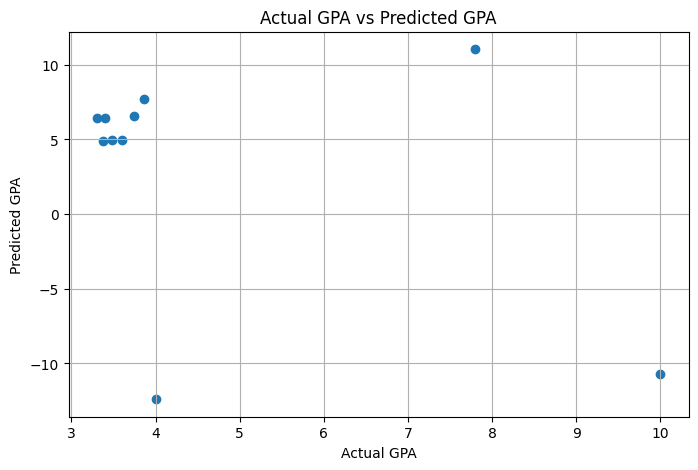

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(
    Y_test,
    test_prediction
)
plt.xlabel(
    "Actual GPA"
)
plt.ylabel(
    "Predicted GPA"
)
plt.title(
    "Actual GPA vs Predicted GPA"
)
plt.grid(True)
plt.show()


In [32]:
model_data = {

    "model": model,

    "scaler": scaler,

    "encoder": encoder
}
with open(
    "linear_regression_model.pkl",
    "wb"
) as file:

    pickle.dump(
        model_data,
        file
    )
print("\nModel Saved Successfully")


Model Saved Successfully


In [33]:
with open(
    "linear_regression_model.pkl",
    "rb"
) as file:

    loaded_model = pickle.load(file)
print("\nModel Loaded Successfully")



Model Loaded Successfully


In [34]:
print("FINAL OBSERVATION")
print(
    "1. Missing values and duplicate records were removed."
)
print(
    "2. Numerical features were converted into proper numeric format."
)
print(
    "3. The nominal feature 'Internships Interests' was encoded using Label Encoding."
)
print(
    "4. Feature scaling was applied using StandardScaler."
)
print(
    "5. Linear Regression model was successfully trained."
)
print(
    "6. Model performance was evaluated using MAE, MSE, RMSE and R2 Score."
)
print(
    "7. Training and testing scores were compared to analyze overfitting."
)
print(
    "8. Possible methods to reduce overfitting:"
)
print(
    "- Feature selection"
)
print(
    "- Cross-validation"
)
print(
    "- Removing irrelevant variables"
)
print(
    "- Increasing training data"
)
print(
    "- Applying regularization techniques like Ridge or Lasso Regression"
)

FINAL OBSERVATION
1. Missing values and duplicate records were removed.
2. Numerical features were converted into proper numeric format.
3. The nominal feature 'Internships Interests' was encoded using Label Encoding.
4. Feature scaling was applied using StandardScaler.
5. Linear Regression model was successfully trained.
6. Model performance was evaluated using MAE, MSE, RMSE and R2 Score.
7. Training and testing scores were compared to analyze overfitting.
8. Possible methods to reduce overfitting:
- Feature selection
- Cross-validation
- Removing irrelevant variables
- Increasing training data
- Applying regularization techniques like Ridge or Lasso Regression
